# Objectif 

Fichiers preprocessés :

* Données de positions : acouplane_pos.nc
* Données de pression : acouplane_raw_pressure.nc

Date de création : 05/10/2026

In [1]:
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.io import loadmat
from datetime import datetime, timedelta

In [2]:
ROOT_PROGRAM = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
sys.path.append(ROOT_PROGRAM)
from publication.publication_figure import set_subfigures_abc_labels, color
from real_data_analysis.acouplane.src.acouplane_cst import *
from real_data_analysis.acouplane.src.acouplane_utils import *

# Données de position

## Chargement des données 

In [3]:
ds_pos = xr.open_dataset(ACOUPLANE_POSITIONS_NC_FPATH)
ds_pos

<xarray.Dataset> Size: 525MB
Dimensions:         (rcv_id: 7, atl_datetime: 563739, mmsi: 526,
                     ais_datetime: 60447, src_datetime: 33608)
Coordinates:
  * rcv_id          (rcv_id) <U4 112B 'OBS1' 'OBS2' 'OBS4' ... 'OBS7' 'TLQ'
  * atl_datetime    (atl_datetime) datetime64[ns] 5MB 2026-02-24 ... 2026-03-...
  * ais_datetime    (ais_datetime) datetime64[ns] 484kB 2026-02-23T23:59:50 ....
  * src_datetime    (src_datetime) datetime64[ns] 269kB 2026-02-24T20:14:06.6...
Dimensions without coordinates: mmsi
Data variables:
    rcv_lon         (rcv_id) float64 56B ...
    rcv_lat         (rcv_id) float64 56B ...
    atl_lon         (atl_datetime) float64 5MB ...
    atl_lat         (atl_datetime) float64 5MB ...
    ais_lon         (mmsi, ais_datetime) float64 254MB ...
    ais_lat         (mmsi, ais_datetime) float64 254MB ...
    tir_SEGD        (src_datetime) int64 269kB ...
    tir_ECOS        (src_datetime) int64 269kB ...
    tir_src_lon     (src_datetime) float64 269kB ...
    tir_src_lat     (src_datetime) float64 269kB ...
    tir_vessel_lon  (src_datetime) float64 269kB ...
    tir_vessel_lat  (src_datetime) float64 269kB ...
Attributes:
    description:              Positions AIS interpolées
    interpolation_time_step:  10s
    campagne:                 ACOUPLANE
    geodesic_frame:           WGS84

In [21]:
def plot_obs_pos(ds_pos, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    for id in ds_pos.rcv_id.values:
        rcv = ds_pos.sel(rcv_id=id)
        plt.scatter(rcv.rcv_lon, rcv.rcv_lat, marker="d", label=f"{id}", s=200)

    ax.set_xlabel("Longitude [°]")
    ax.set_ylabel("Latitude [°]")
    ax.set_title("OBS positions")
    ax.legend()

    return ax

### Trajectoire ATALANTE

<Axes: title={'center': 'OBS positions'}, xlabel='Longitude [°]', ylabel='Latitude [°]'>

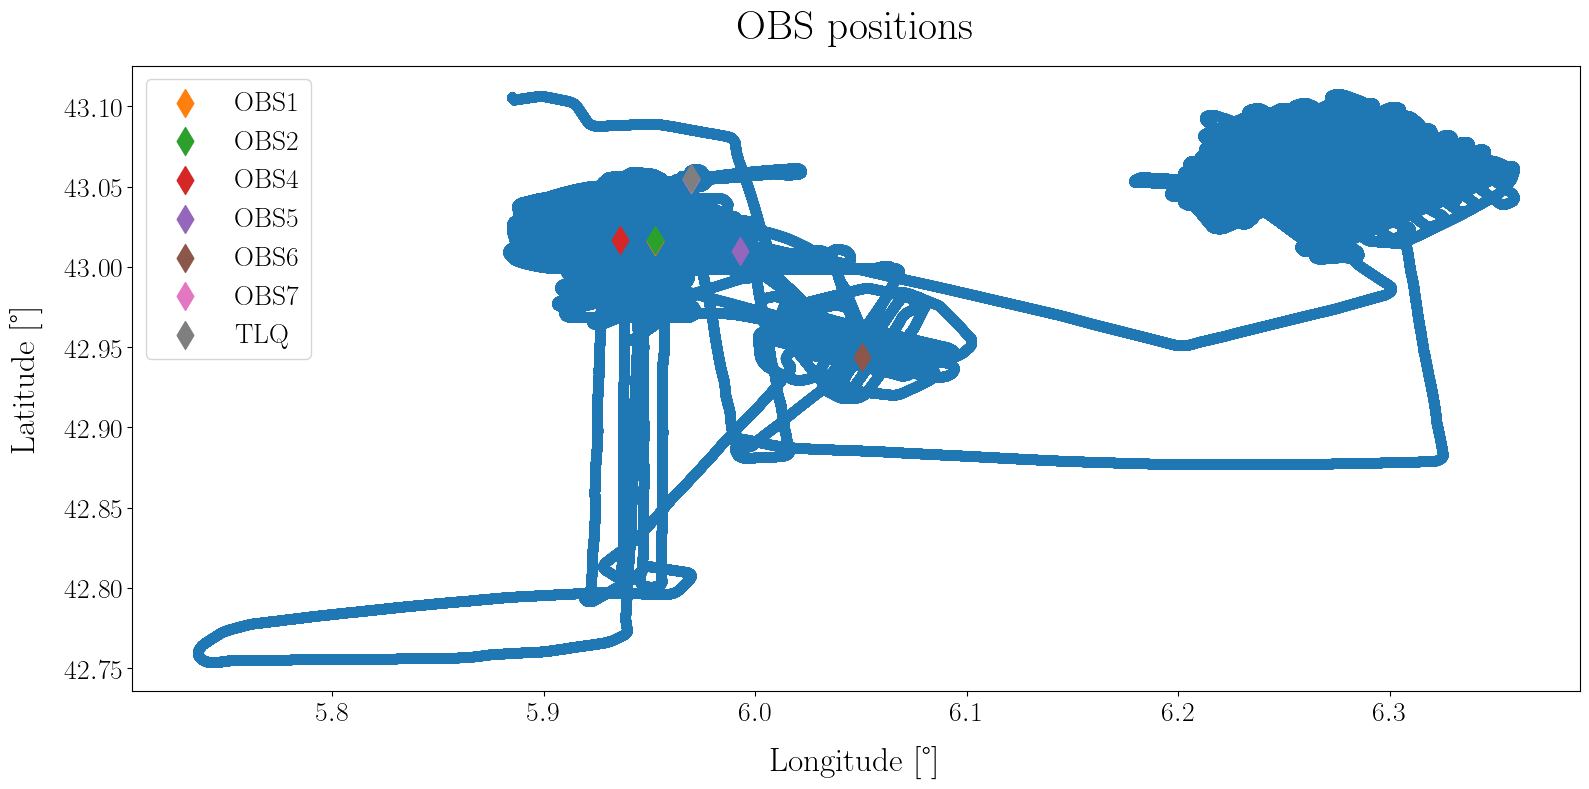

In [24]:
plt.figure()
ax = plt.gca()
plt.scatter(ds_pos.atl_lon, ds_pos.atl_lat)
plot_obs_pos(ds_pos, ax=ax)

# Données de pression

## Chargement des données 

In [4]:
ds_pressure = xr.open_dataset(ACOUPLANE_PRESSURE_NC_FPATH)

## Example de chargement des données à partir de ce fichier 

Les données stockées sont les données raw, il faut donc les convertir et fabriquer le vecteur de temps.

In [5]:
# Convert to volts
ds_pressure = convert_raw_pressure_to_physical_units(ds_pressure=ds_pressure)

In [6]:
ds_pressure

<xarray.Dataset> Size: 2GB
Dimensions:         (time_obs1: 100014000, time_obs2: 100034000, obs_id: 2)
Coordinates:
  * obs_id          (obs_id) <U4 32B 'obs1' 'obs2'
Dimensions without coordinates: time_obs1, time_obs2
Data variables:
    pressure_obs1   (time_obs1) float64 800MB 0.03867 0.02945 ... 0.0566 0.05001
    pressure_obs2   (time_obs2) float64 800MB 0.02267 0.0273 ... 0.03432 0.03432
    start_datetime  (obs_id) datetime64[ns] 16B ...
Attributes:
    description:  Données de pression (voie hydro 3)
    campagne:     ACOUPLANE
    fs:           2000
    fullscale:    4.52

In [7]:
# Build a vector of datetime for each OBS signal
obs_datetimes = build_obs_datetime_vector(ds_pressure=ds_pressure)

In [9]:
# Slice the dataset to a specific time range
start_dt = datetime(2026, 2, 24, 14, 0, 0)
stop_dt = datetime(2026, 2, 24, 15, 20, 0)

obs1_slice_idx = (
    np.where(obs_datetimes["obs1"] >= start_dt)[0][0],
    np.where(obs_datetimes["obs1"] <= stop_dt)[0][-1],
)
obs2_slice_idx = (
    np.where(obs_datetimes["obs2"] >= start_dt)[0][0],
    np.where(obs_datetimes["obs2"] <= stop_dt)[0][-1],
)
pressure_slice = ds_pressure.isel(
    time_obs1=slice(
        obs1_slice_idx[0],
        obs1_slice_idx[1] + 1,
    ),
    time_obs2=slice(obs2_slice_idx[0], obs2_slice_idx[1] + 1),
)
pressure_slice["time_obs1"] = obs_datetimes["obs1"][
    obs1_slice_idx[0] : obs1_slice_idx[1] + 1
]
pressure_slice["time_obs2"] = obs_datetimes["obs2"][
    obs2_slice_idx[0] : obs2_slice_idx[1] + 1
]
pressure_slice["time_obs1"].attrs = {"unit": "UTC", "long_name": "Time"}
pressure_slice["time_obs2"].attrs = {"unit": "UTC", "long_name": "Time"}

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


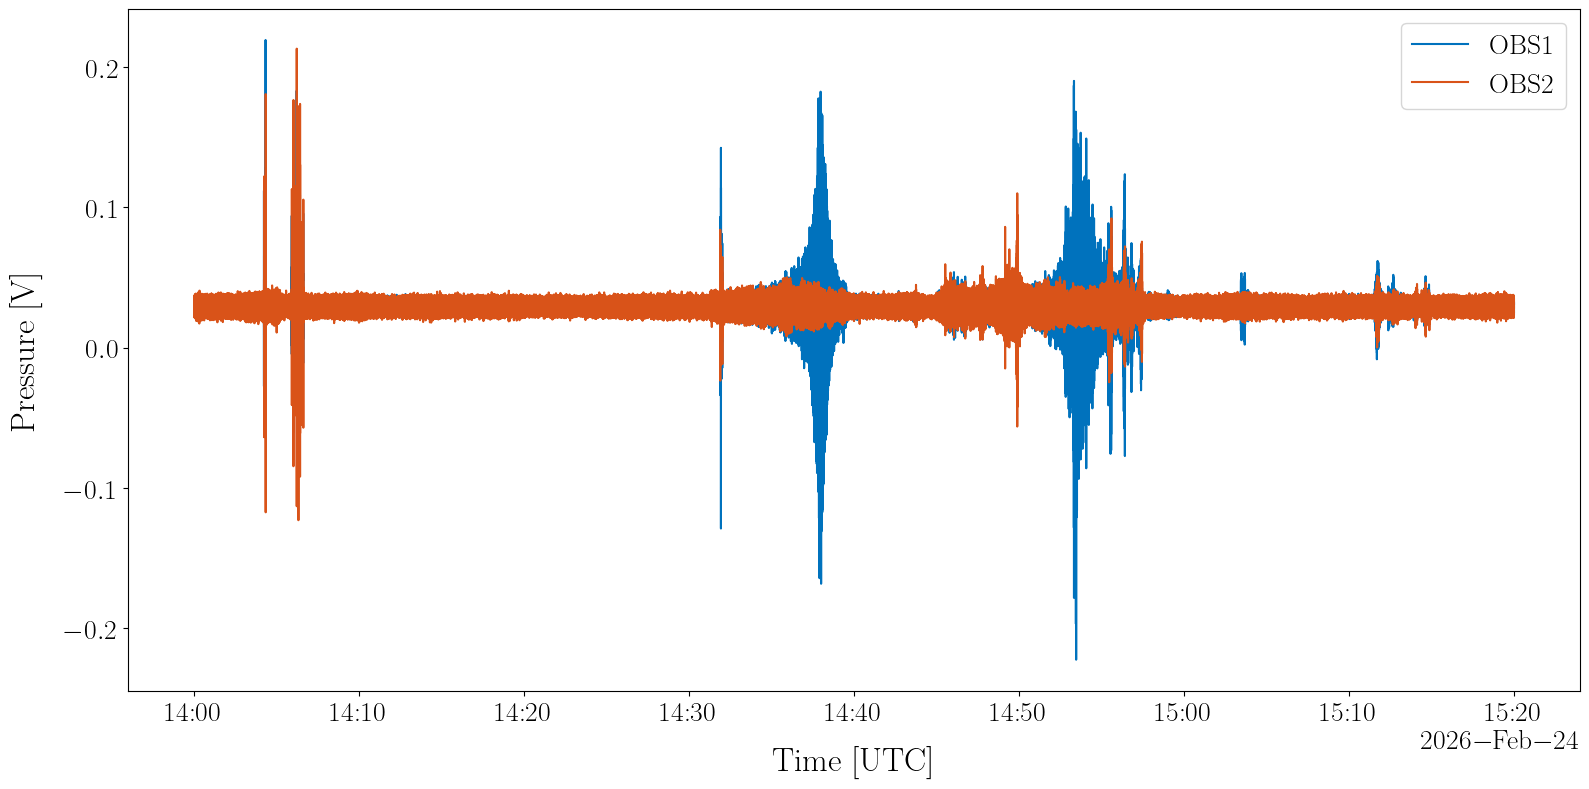

In [12]:
plt.figure()
pressure_slice.pressure_obs1.plot(label="OBS1", color=color(0))
pressure_slice.pressure_obs2.plot(label="OBS2", color=color(1))
plt.legend()